In [1]:
import os
import inspect
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from utils import train, coords_2_strain_nn
from utils import train_colloc_parallel as train_colloc, init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso, init_params_aniso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity
from fem import plotmesh, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax,plotmesh_updated

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))

def ty(a):
    b = type(a)  # Get the type of `a`
    print(b)  # Print the type
    
    if isinstance(a, np.ndarray): 
        return b, a.shape
    else:
        return b, len(a)  



       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



## 1. Generate data + pretraining

In [2]:
##########################################################################this is I am using to understand the above code##### skip it when you run the code
print(inspect.getsource(Mesh))

class Mesh():
    """
    A custom mesh manager might be better using a third-party library like
    meshio.
    """
    def __init__(self, points, cells, ele_type='TET4'):
        # TODO: Assert that cells must have correct orders
        # TODO: first cells, then points?
        self.points = points
        self.cells = cells
        self.ele_type = ele_type

    def count_selected_faces(self, location_fn):
        """Given location functions, compute the count of faces that satisfy
        the location function. Useful for setting up distributed load
        conditions.

        Parameters
        ----------
        location_fns : List[Callable]
            Callable: a function that inputs a point and returns a boolean
            value describing whether the boundary condition should be applied.

        Returns
        -------
        face_count : int
        """

        _, _, _, _, face_inds = get_face_shape_vals_and_grads(self.ele_type)
        cell_points = onp.take(self.point

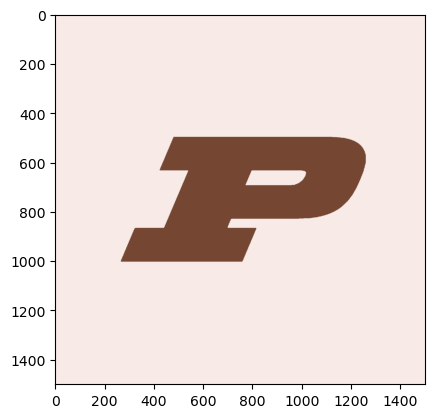

In [3]:
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

# Define your custom colormap (light to dark orange)
orange_cmap = LinearSegmentedColormap.from_list(
    "dark_to_light_orange", ["#754732" ,"#f7eae7", ], N=256
)
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = 100, 100
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
image = Image.open('/home/amir/inverse_prob/PP.png')
# image = image.filter(ImageFilter.GaussianBlur(radius=60))
plt.imshow(image,cmap=orange_cmap)
image = image.rotate(-90)
image = np.array(image)
#image = image.mean(axis=2)
image = image/image.max()

pts_x = np.linspace(0,1,image.shape[0])
pts_y = np.linspace(0,1,image.shape[1])

def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    ##### image size is 1500 by 1500 but the range of values are x,y, pts_x and pts_y are between [0,1]
    return jnp.stack([0.5,0.10,0.20,0.1,0.0]) + c*jnp.stack([0.2,0.02,0.04,0.0,0.0])

In [4]:
GOH_P_vmap = vmap(ThreeDElasticity(GOH_model).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(GOH_model).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [5]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
print(mesh)

# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny
F_hist_goh = []
P_hist_goh = []
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    # params = vmap(coords_2_params_gt)(elem_X)
    params = []
    for xy in elem_X:
        params.append(coords_2_params_gt(xy))
    params = np.expand_dims(params, 1)
    params_vec = jnp.repeat(params, axis=1, repeats=4)
    problem.set_params(params_vec)


    u = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    F = u_grad + np.eye(2)

    P = GOH_P_vmap(u_grad, params_vec[:,00,:], 2)
    
    F_hist_goh.append(F)
    P_hist_goh.append(P)
F_hist_goh = np.array(F_hist_goh)
P_hist_goh = np.array(P_hist_goh)

[06-13 19:24:03][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[06-13 19:24:03][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[06-13 19:24:03][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)


[06-13 19:24:04][DEBUG] jax_fem: Done pre-computations, took 0.8394603729248047 [s]
[06-13 19:24:04][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[06-13 19:24:07][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[06-13 19:24:07][DEBUG] jax_fem: Start timing
[06-13 19:24:07][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[06-13 19:24:09][DEBUG] jax_fem: Function split_and_compute_cell took 1.7438 seconds
[06-13 19:24:10][DEBUG] jax_fem: Creating sparse matrix with scipy...
[06-13 19:24:10][DEBUG] jax_fem: Linear guess solve...
[06-13 19:24:10][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[06-13 19:24:10][DEBUG] jax_fem: PETSc linear solve res = 3.135234039341322e-06
[06-13 19:24:10][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[06-13 19:24:10][DEBUG] jax_fem: Function split_and_compute_cell took 0.0403 seconds
[06-13 19:24:10][DEBUG] jax_fem: Creating sparse matrix with scipy...
[06-1

### we want to plot the following with the same range

In [8]:
max_min_range=np.zeros((2,))
strains = []
t_hist = np.arange(len(lmb_hist))
for t, F, P in zip(t_hist, F_hist_goh, P_hist_goh):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    print(evals.shape)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    if t==0:
        max_min_range[0]=np.min(mps)
        max_min_range[1]=np.max(mps)
    else:
        max_min_range[0]=np.min([np.min(mps),max_min_range[0]])
        max_min_range[1]=np.max([np.max(mps),max_min_range[1]])



(2500, 2)
(2500, 2)
(2500, 2)
(2500, 2)


(2500, 2)
(2500, 2)
(2500, 2)
(2500, 2)


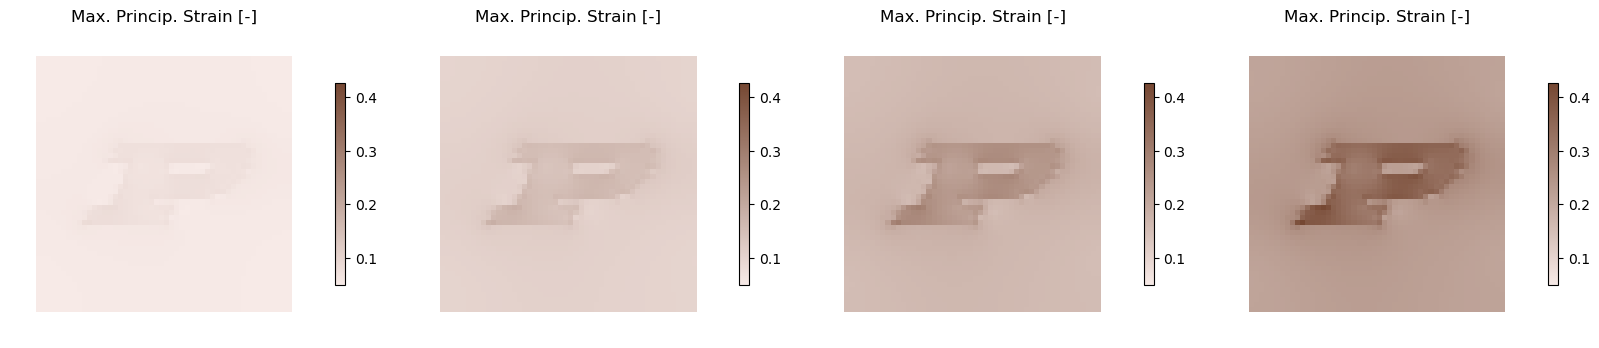

In [9]:

natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)

fig, axes = plt.subplots(1,4,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
for t, F, P, ax in zip(t_hist, F_hist_goh, P_hist_goh, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    print(evals.shape)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    plotmesh_updated(mesh.cells, mesh.points, mps, max_min_range[0],max_min_range[1],title='Max. Princip. Strain [-]', ax=ax,ec='None',cmap=natural_brown_cmap)

    strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
strains = np.hstack(strains)

### Coords_2_strain NN

In [8]:
# instead of using a 2D spline, use a NN to get the strain field for a given (x,y)
def loss_coords_2_strain(params, X, key):
    inp, out_gt = X[:,:3], X[:,3:] #inp: x,y,lmb and out_gt=eps_xx, eps_yy
    t = inp[:,2:3]
    out_pr = coords_2_strain_nn(inp, params)
    out_gt = out_gt/(t+1) #dividing by t+1 just for some regularization
    out_pr = out_pr/(t+1) #dividing by t+1 just for some regularization
    return jnp.mean((out_pr-out_gt)**2)

n_ff = 40 
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5
nn_layers = [2*n_ff+1,40,40,4]
nn_params = init_params_nn(nn_layers, key)
coord_2_strain_params = [ff_params, nn_params]
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
opt_init, opt_update, get_params = optimizers.adam(5.e-4)
opt_state = opt_init(coord_2_strain_params)
X = np.vstack([elem_X, elem_X, elem_X, elem_X])
inp = np.hstack([X, strains.T])
coord_2_strain_params, train_loss, _ = train(loss_coords_2_strain, inp, get_params, opt_update, opt_state, key, nIter = 100000, print_freq=1000, batch_size=1000)

it 1000, train loss = 8.781763e-05
it 2000, train loss = 3.575075e-05
it 3000, train loss = 2.144886e-05
it 4000, train loss = 1.743478e-05
it 5000, train loss = 1.533427e-05
it 6000, train loss = 1.268273e-05
it 7000, train loss = 1.228558e-05
it 8000, train loss = 1.287113e-05
it 9000, train loss = 1.082474e-05
it 10000, train loss = 1.128459e-05
it 11000, train loss = 1.089800e-05
it 12000, train loss = 1.002167e-05
it 13000, train loss = 1.072182e-05
it 14000, train loss = 1.196828e-05
it 15000, train loss = 1.234149e-05
it 16000, train loss = 9.553683e-06
it 17000, train loss = 1.386789e-05
it 18000, train loss = 1.079124e-05
it 19000, train loss = 1.028571e-05
it 20000, train loss = 8.680604e-06
it 21000, train loss = 1.069677e-05
it 22000, train loss = 8.893863e-06
it 23000, train loss = 8.069255e-06
it 24000, train loss = 8.265549e-06
it 25000, train loss = 8.581672e-06
it 26000, train loss = 8.856420e-06
it 27000, train loss = 7.618381e-06
it 28000, train loss = 8.473754e-06
i

In [9]:
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)

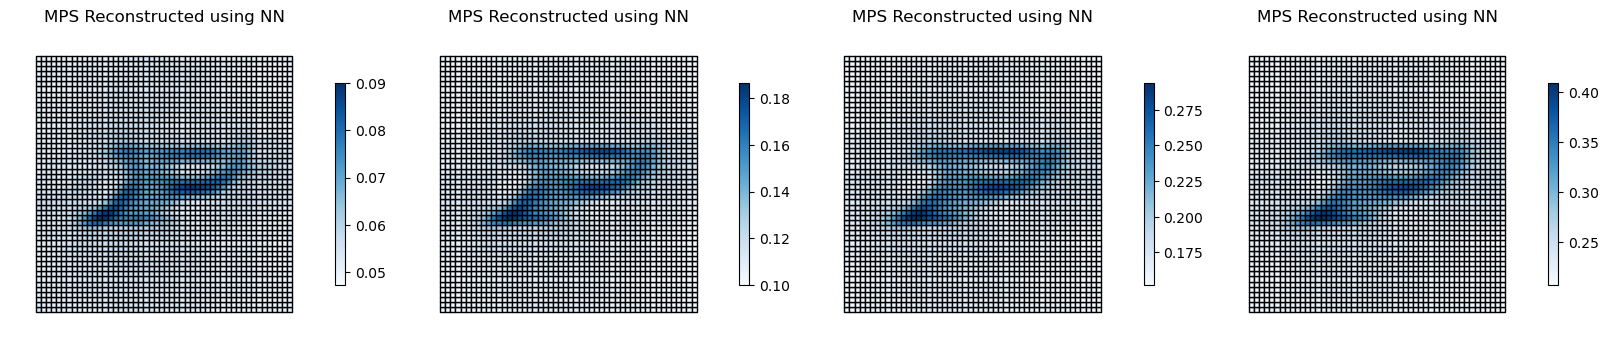

In [11]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
for t in t_hist:
    ax = axes[t]
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    plotmesh(mesh.cells, mesh.points, mps, title='MPS Reconstructed using NN', ax=ax); 

In [12]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = np.sum(P_hist_goh[:,rgt_bd_elems,0,0], axis=1)
lft_bd_frc = np.sum(P_hist_goh[:,lft_bd_elems,0,0], axis=1)
top_bd_frc = np.sum(P_hist_goh[:,top_bd_elems,1,1], axis=1)
bot_bd_frc = np.sum(P_hist_goh[:,bot_bd_elems,1,1], axis=1)
Force_x = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Force_y = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [ ]:
# Homogenize the strains
F_xx_mean = np.mean(F_hist_goh[:,:,0,0], axis=1)
F_xy_mean = np.mean(F_hist_goh[:,:,0,1], axis=1)
F_yx_mean = np.mean(F_hist_goh[:,:,1,0], axis=1)
F_yy_mean = np.mean(F_hist_goh[:,:,1,1], axis=1)

P_xx_mean = Force_x/len(rgt_bd_elems)
P_yy_mean = Force_y/len(top_bd_elems)
inputs = np.array([F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, P_xx_mean, P_yy_mean]).T

n_neurons = 4
#Define the loss function for when training all params
@jit
def loss_stress(params, x, key):
    model = NODE_model_aniso(params)
    F_xx, F_xy, F_yx, F_yy, P_xx_gt, P_yy_gt = x.T
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr-P_xx_gt)**2+(P_yy_pr-P_yy_gt)**2)

# Initialize NODEs and the optimizer
key = random.PRNGKey(0)
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_aniso(common_layers, sample_layers, key)
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(node_params)

# Train
node_params, train_loss, _ = train(loss_stress, inputs, get_params, opt_update, opt_state, key, nIter = 20000, print_freq=1000)

In [14]:
mymodel = NODE_model_aniso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_mean, P_yy_mean)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)

gt P_xx & P_yy:  [0.36949 0.67047 0.92346 1.14297] [0.35553 0.63957 0.87244 1.06829]
pr P_xx & P_yy:  [0.36815 0.67293 0.92148 1.14357] [0.35424 0.64203 0.87041 1.06892]


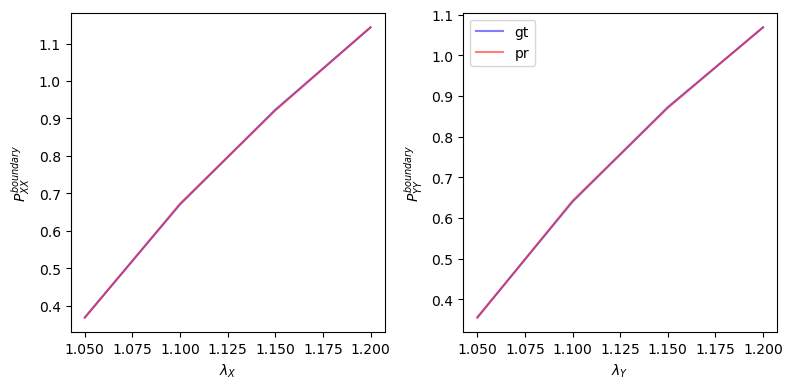

In [15]:
lmb_hist = [1.05, 1.10, 1.15, 1.20]
fig, ax=plt.subplots(1,2, figsize=(8, 4))
ax[0].plot(lmb_hist,P_xx_mean,label='gt',alpha=0.5,color='blue')
ax[0].plot(lmb_hist,P_xx_pr, label='pr',alpha=0.5,color='red')
ax[0].set_ylabel(r'$P_{XX}^{boundary}$')
ax[0].set_xlabel(r'$\lambda_{X}$')
ax[1].plot(lmb_hist,P_yy_mean,label='gt',alpha=0.5,color='blue')
ax[1].plot(lmb_hist,P_yy_pr, label='pr',alpha=0.5,color='red')
ax[1].set_ylabel(r'$P_{YY}^{boundary}$')
ax[1].set_xlabel(r'$\lambda_{Y}$')
ax[1].legend()
plt.tight_layout()
plt.show()

#### plot in the boundary force distribution in the same plots

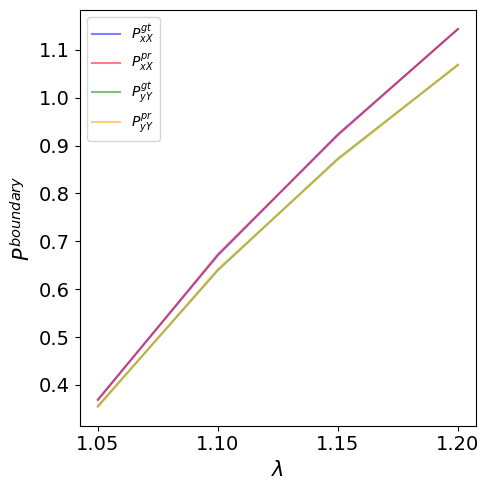

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(lmb_hist, P_xx_mean, label=r'$P_{xX}^{gt}$', alpha=0.5, color='blue')
ax.plot(lmb_hist, P_xx_pr, label=r'$P_{xX}^{pr}$', alpha=0.5, color='red')

ax.plot(lmb_hist, P_yy_mean, label=r'$P_{yY}^{gt}$', alpha=0.5, color='green')
ax.plot(lmb_hist, P_yy_pr, label=r'$P_{yY}^{pr}$', alpha=0.5, color='orange')
ax.set_xlabel(r'$\lambda$',fontsize=15)
ax.set_ylabel(r'$P^{boundary}$',fontsize=15)
ax.tick_params(axis='both', labelsize=14)
ax.get_xlim()
ax.get_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

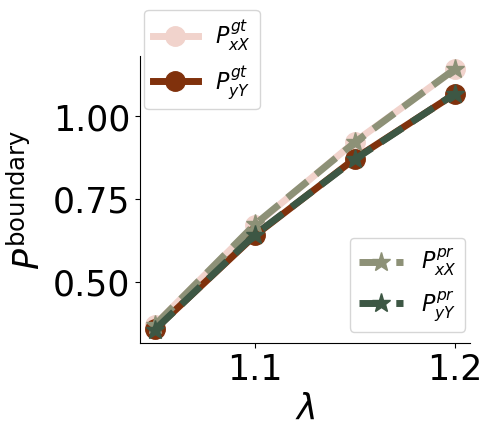

In [17]:
light_brown = "#f1d3cc"
dark_brown = "#80310C"
light_green = "#8D9177" 
dark_green = "#3D5744"

fig, ax = plt.subplots(figsize=(5, 4))

# Ground truth curves
line1, = ax.plot(lmb_hist, P_xx_mean, label=r'$P_{xX}^{gt}$', color=light_brown, linewidth=5, linestyle='-', marker='o', markersize=14)
line2, = ax.plot(lmb_hist, P_yy_mean, label=r'$P_{yY}^{gt}$', color=dark_brown, linewidth=5, linestyle='-', marker='o', markersize=14)

# Predicted curves
line3, = ax.plot(lmb_hist, P_xx_pr, label=r'$P_{xX}^{pr}$', color=light_green, linewidth=5, linestyle='--', marker='*', markersize=14)
line4, = ax.plot(lmb_hist, P_yy_pr, label=r'$P_{yY}^{pr}$', color=dark_green, linewidth=5, linestyle='--', marker='*', markersize=14)

# Add legends separately
legend1 = ax.legend(handles=[line1, line2], fontsize=16, loc='upper left', bbox_to_anchor=(-0.02, 1.2))
ax.add_artist(legend1)
legend2 = ax.legend(handles=[line3, line4], fontsize=16, loc='lower right', bbox_to_anchor=(1.02, 0))

# Axes and labels
ax.set_xlabel(r'$\lambda$', fontsize=25)
ax.set_ylabel(r'$P^{\text{boundary}}$', fontsize=25)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=25)

plt.tight_layout()
plt.show()


In [17]:
# Fit a function Λ that maps x,y ∈ [0,1] to the individual-specific parameters of this NODE with a maximum variance of, say, 1%
phi, unravel = ravel_pytree(node_params)
n_phi = len(phi)

# ff_params = coord_2_sΛ train_params[0]
# ff_nn2 = lambda x, nn_params: ff_nn(x, [ff_params, nn_params])
def loss_Lambda(params, inp, key):
    out_pr = ff_nn(inp, params)
    return jnp.mean((out_pr-phi)**2)

n_ff = 40
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,40,40,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
ff_nn_ff = lambda x, params: ff_nn(x, params)
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

inp = np.array(np.meshgrid(np.linspace(0,1,20), np.linspace(0,1,20))).reshape([2,-1]).T
Lambda_params, train_loss, _ = train(loss_Lambda, inp, get_params, opt_update, opt_state, key, nIter = 10000, print_freq=1000)

it 1000, train loss = 1.379280e-04
it 2000, train loss = 4.023589e-05
it 3000, train loss = 1.685600e-05
it 4000, train loss = 8.190059e-06
it 5000, train loss = 4.326254e-06
it 6000, train loss = 2.344377e-06
it 7000, train loss = 1.319543e-06
it 8000, train loss = 7.499026e-07
it 9000, train loss = 4.683897e-07
it 10000, train loss = 2.777146e-07


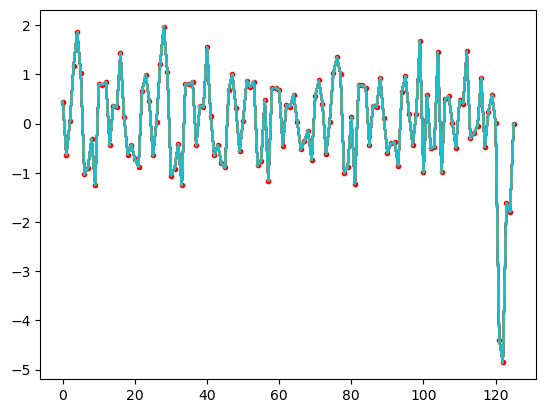

In [19]:
phi, unravel = ravel_pytree(node_params)
fig, ax = plt.subplots()
ax.plot(phi, 'r.-')
for y in np.linspace(0,1,4):
    for x in np.linspace(0,1,10):
        params = ff_nn(np.array([x,y]).reshape([1,-1]), Lambda_params)
        ax.plot(params[0])

In [19]:
with open('params_purdue_pre_paper_ablation_FF_40.npy', 'wb') as f:
    pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains,
                 bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist], f)

In [6]:
with open('params_purdue_pre_paper_ablation_FF_40.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains,\
        bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist = pickle.load(f)

In [7]:
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)

In [ ]:
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y
#%%
# Train
a1 = 10000
@jit
def loss(Lambda_params, XYt_colloc):

    P_pred = get_P_vmap(XYt_colloc[:,0],XYt_colloc[:,1], XYt_colloc[:,2], Lambda_params, coord_2_strain_params, NODE_w_unravel)
    P_xx = P_xx_mean[jnp.array(XYt_colloc[:,2], int)]
    P_yy = P_yy_mean[jnp.array(XYt_colloc[:,2], int)]

    loss_P = jnp.mean((P_pred[0] - P_xx)**2 + (P_pred[3] - P_yy)**2)
    # loss_F = 0.0
    
    return loss_P

lr = optimizers.exponential_decay(1e-3, 10000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 30000, print_freq=1000, batch_size=1000)

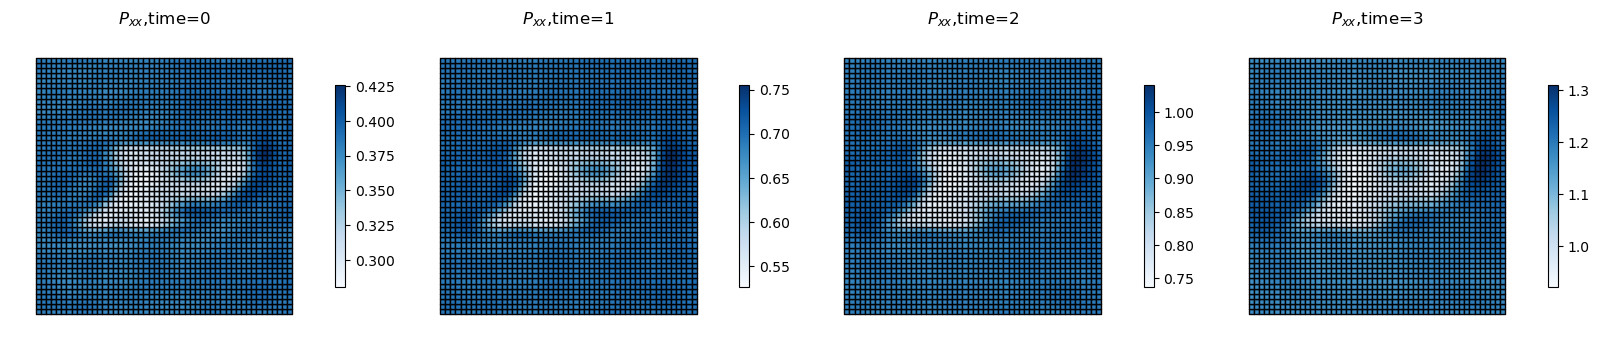

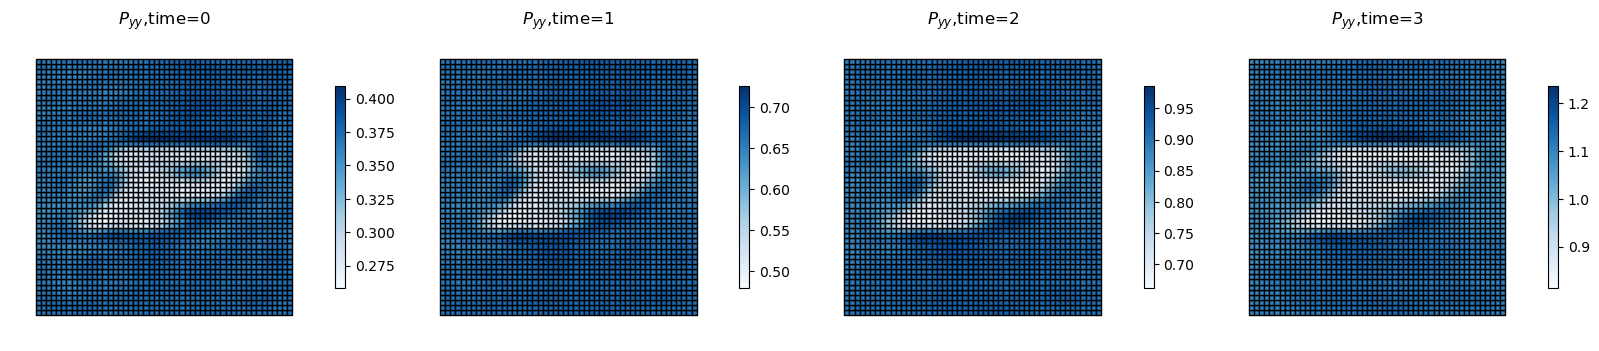

In [23]:
def get_P_pretraining_plot(F, X,Y,Lambda_params, model):
    F_xx=F[0,0]
    F_xy=F[0,1]
    F_yx=F[1,0]
    F_yy=F[1,1]
    #F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_pretraining_plot_vmap = vmap(get_P_pretraining_plot, in_axes=(0,0,0,None,None), out_axes=(0,0,0,0))
lmb_hist_plot = [1.05, 1.10, 1.15, 1.20]
t_hist = len(lmb_hist_plot )
n_plots = len(lmb_hist_plot)  
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols 
t_hist =np.arange(0, t_hist)
# c_range=np.ones((n_cols,2))
# c_range[:,[0]]=100000*c_range[:,[0]]
# c_range[:,[1]]=-100000*c_range[:,[1]]
ff_nn_ff = lambda x, params: ff_nn(x, params)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
id_for_range=0
fig_x, axes_x = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_x = axes_x.flatten()
fig_y, axes_y = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_y = axes_y.flatten()
for lam in lmb_hist_plot:
    ax_x = axes_x[id_for_range]
    ax_y = axes_y[id_for_range]
    uniform_F= lam *np.eye(2).reshape(1, 2, 2)
    uniform_F_batch= np.repeat(uniform_F, elem_X.shape[0], axis=0)
    P_xx, P_xy,P_yx,P_yy=get_P_pretraining_plot_vmap(uniform_F_batch, elem_X[:,0],elem_X[:,1],Lambda_params,NODE_w_unravel)
    title=fr'$P_{{xx}}$,time={id_for_range}'
    plotmesh(mesh.cells, mesh.points, P_xx,title=title, ax=ax_x)
    title=fr'$P_{{yy}}$,time={id_for_range}'
    plotmesh(mesh.cells, mesh.points, P_yy,title=title, ax=ax_y)
    id_for_range+=1

In [24]:
with open('purdue_prob_paper_second_pretraining_ablation_FF_40.pickle', 'wb') as f:
    pickle.dump([Lambda_params,val_loss, metrics], f)

In [8]:
with open('purdue_prob_paper_second_pretraining_ablation_FF_40.pickle', 'rb') as f:
    Lambda_params,val_loss, metrics = pickle.load(f)

## 2. Retrain

In [9]:
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [10]:
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y

In [26]:
# Train
a1 = 10000
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = a1*(Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        Fx = Force_x[jnp.array(t, int)]
        Fy = Force_y[jnp.array(t, int)]
        return None, a2*((F_rgt-Fx)**2 + (F_top-Fy)**2 + (F_lft-Fx)**2 + (F_bot-Fy)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    # loss_F = 0.0
    
    return loss_Div + loss_F

lr = 1e-4
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 20000, print_freq=1000, batch_size=1000)

2025-06-09 00:27:04.207063: E external/xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2025-06-09 00:29:12.515681: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 4m8.308552535s

********************************
[Compiling module jit_step_colloc] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


it 1, val loss = 1.087573e+00
it 1001, val loss = 4.932105e-01
it 2001, val loss = 4.995023e-01
it 3001, val loss = 6.246142e-01
it 4001, val loss = 6.172464e-01
it 5001, val loss = 1.529101e-01
it 6001, val loss = 4.733836e-01
it 7001, val loss = 6.050862e-01
it 8001, val loss = 8.342403e-01
it 9001, val loss = 8.979743e-01
it 10001, val loss = 3.164745e-01
it 11001, val loss = 6.617315e-01
it 12001, val loss = 2.217695e-01
it 13001, val loss = 4.731802e-01
it 14001, val loss = 8.229080e-01
it 15001, val loss = 1.808540e-01
it 16001, val loss = 8.496022e-01
it 17001, val loss = 4.678831e-01
it 18001, val loss = 6.125066e-01
it 19001, val loss = 6.891048e-01


In [27]:
with open('purde_prob_paper_post_ablation_FF_40.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist], f)

## 3. Test

In [11]:
with open('purde_prob_paper_post_ablation_FF_40.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [12]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = np.sum(P_hist_goh[:,rgt_bd_elems,0,0], axis=1)
lft_bd_frc = np.sum(P_hist_goh[:,lft_bd_elems,0,0], axis=1)
top_bd_frc = np.sum(P_hist_goh[:,top_bd_elems,1,1], axis=1)
bot_bd_frc = np.sum(P_hist_goh[:,bot_bd_elems,1,1], axis=1)
Force_x = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Force_y = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [13]:
F_xx_mean = np.mean(F_hist_goh[:,:,0,0], axis=1)
F_xy_mean = np.mean(F_hist_goh[:,:,0,1], axis=1)
F_yx_mean = np.mean(F_hist_goh[:,:,1,0], axis=1)
F_yy_mean = np.mean(F_hist_goh[:,:,1,1], axis=1)

P_xx_mean = Force_x/len(rgt_bd_elems)
P_yy_mean = Force_y/len(top_bd_elems)
mymodel = NODE_model_aniso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_mean, P_yy_mean)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)

gt P_xx & P_yy:  [0.36949 0.67047 0.92346 1.14297] [0.35553 0.63957 0.87244 1.06829]
pr P_xx & P_yy:  [0.36815 0.67293 0.92148 1.14357] [0.35424 0.64203 0.87041 1.06892]


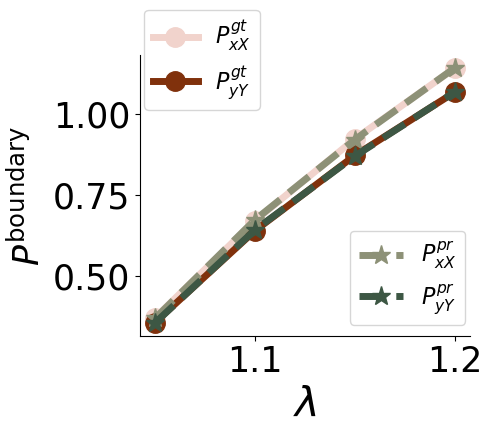

In [14]:
light_brown = "#f1d3cc"
dark_brown = "#80310C"
light_green = "#8D9177" 
dark_green = "#3D5744"

fig, ax = plt.subplots(figsize=(5, 4))

# Ground truth curves
line1, = ax.plot(lmb_hist, P_xx_mean, label=r'$P_{xX}^{gt}$', color=light_brown, linewidth=5, linestyle='-', marker='o', markersize=14)
line2, = ax.plot(lmb_hist, P_yy_mean, label=r'$P_{yY}^{gt}$', color=dark_brown, linewidth=5, linestyle='-', marker='o', markersize=14)

# Predicted curves
line3, = ax.plot(lmb_hist, P_xx_pr, label=r'$P_{xX}^{pr}$', color=light_green, linewidth=5, linestyle='--', marker='*', markersize=14)
line4, = ax.plot(lmb_hist, P_yy_pr, label=r'$P_{yY}^{pr}$', color=dark_green, linewidth=5, linestyle='--', marker='*', markersize=14)

# Add legends separately
legend1 = ax.legend(handles=[line1, line2], fontsize=16, loc='upper left', bbox_to_anchor=(-0.02, 1.2))
ax.add_artist(legend1)
legend2 = ax.legend(handles=[line3, line4], fontsize=16, loc='lower right', bbox_to_anchor=(1.02, 0))

# Axes and labels
ax.set_xlabel(r'$\lambda$', fontsize=30)
ax.set_ylabel(r'$P^{\text{boundary}}$', fontsize=25)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=25)

plt.tight_layout()
plt.show()


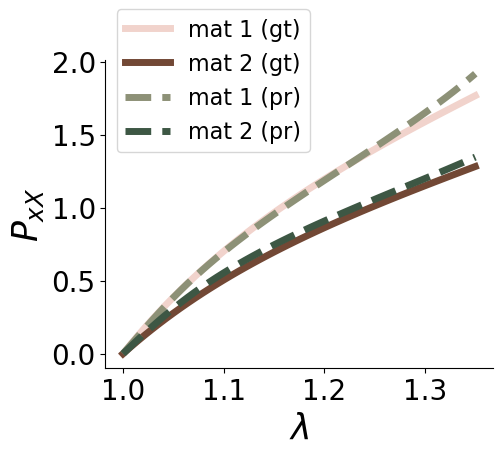

In [15]:
light_brown = "#f1d3cc"
dark_brown = "#724835"
light_green = "#8D9177" 
dark_green = "#3D5744"
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt,'-', label='mat 1 (gt)',color=light_brown, linewidth=5)
ax.plot(lmb_hist2, mat2_P_gt,'-', label='mat 2 (gt)',color=dark_brown, linewidth=5)

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)',color=light_green , linewidth=5)
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)',color=dark_green, linewidth=5)
ax.set_xlabel(r'$\lambda$',fontsize=25)
ax.set_ylabel(r'$P_{xX}$',fontsize=25)
ax.legend(fontsize=16, loc='upper left', bbox_to_anchor=(0, 1.20))
ax.set(xlabel='$\lambda$', ylabel='$P_{xX}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=20)

In [ ]:
fig, axes = plt.subplots(2,4,figsize=(20,8))

In [17]:
range_minmax_gt=np.zeros((2,))
range_minmax_pr=np.zeros((2,))
# Stiffness across the domain
for lmb, ax in zip(lmb_hist,axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0]+\
                         ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[1,1])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0]+\
                         ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    if lmb==1.05:
        range_minmax_gt[0]=np.min(c_elem_gt)
        range_minmax_gt[1]=np.max(c_elem_gt)
        range_minmax_pr[0]=np.min(c_elem_pr)
        range_minmax_pr[1]=np.max(c_elem_pr)
    else:
        range_minmax_gt[0]=np.min([np.min(c_elem_gt),range_minmax_gt[0]])
        range_minmax_gt[1]=np.max([np.max(c_elem_gt),range_minmax_gt[1]])
        range_minmax_pr[0]=np.min([np.min(c_elem_pr),range_minmax_pr[0]])
        range_minmax_pr[1]=np.max([np.max(c_elem_pr),range_minmax_pr[1]])
    

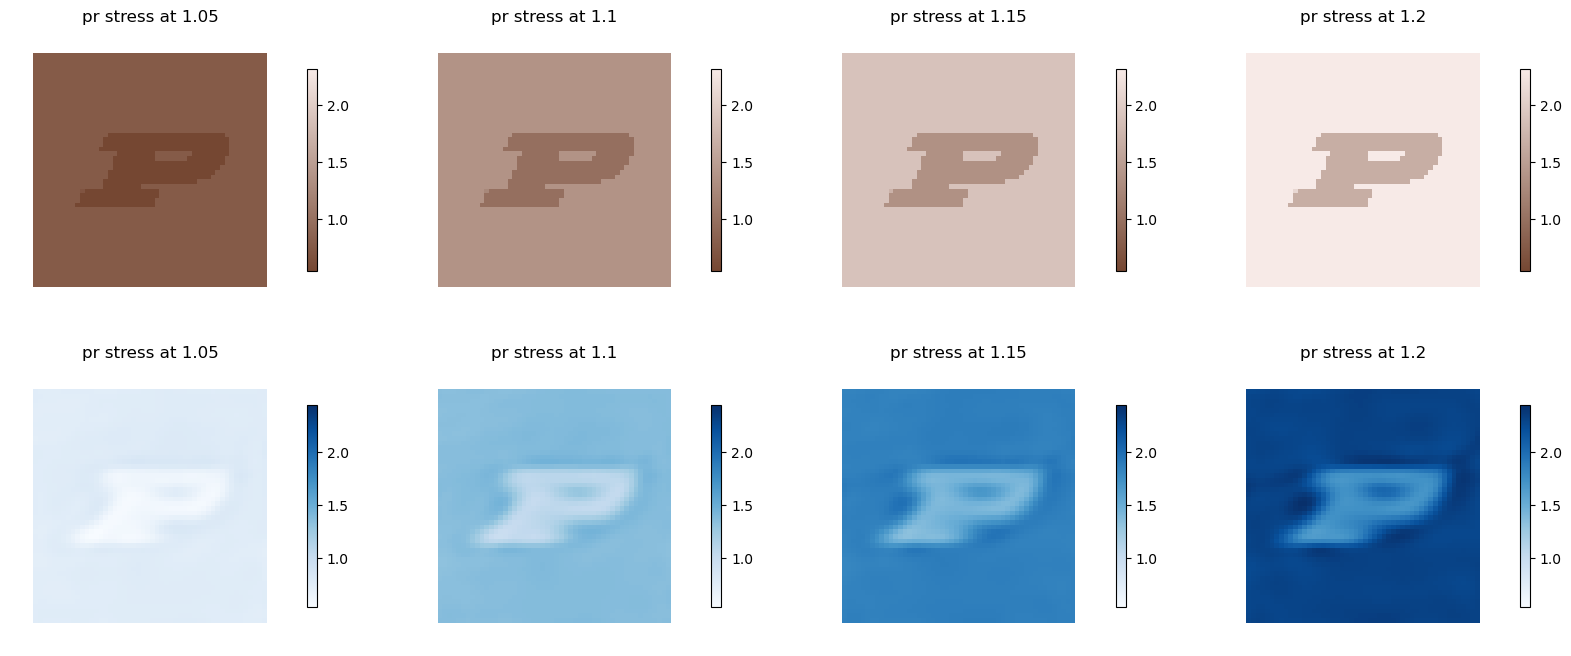

In [18]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0]+\
                         ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[1,1])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0]+\
                         ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    
    #plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0],cmap=orange_cmap ,ec='none'); 
    plotmesh_updated(mesh.cells, mesh.points, c_elem_gt, range_minmax_gt[0],range_minmax_gt[1],title=f'pr stress at {lmb}', ax=ax[0],ec='none',cmap=orange_cmap)
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh_updated(mesh.cells, mesh.points, c_elem_pr, range_minmax_pr[0],range_minmax_pr[1],title=f'pr stress at {lmb}', ax=ax[1],ec='none')

### plots of P's wrt F(X,t)

### calculation for range of plots

In [148]:
##### this is for calculation of the range of predicted stress in material that is why I am deleting the extra calculaitons 
range_minmax=np.zeros((2,))
id_f=0
for lmb, ax in zip(lmb_hist, axes.T):
    F=F_hist_goh[id_f]

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)
    # E = E_fun(F)
    # evals, efuns = jnp.linalg.eigh(E)
    # print(evals.shape)
    E_11, E_22 = evals.T
    c_elem_gt = []
    c_elem_pr = []
    id_elem=0
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        ugrad=jnp.squeeze(F[id_elem,:,:])-jnp.eye(2)
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        id_elem+=1
    if lmb==1.05:
        range_minmax[0]=np.min(c_elem_pr)
        range_minmax[1]=np.max(c_elem_pr)
    else:
        range_minmax[0]=np.min([np.min(c_elem_pr),range_minmax[0]])
        range_minmax[1]=np.max([np.max(c_elem_pr),range_minmax[1]])

    id_f+=1
 

In [149]:
range_minmax

array([0.28469, 1.26014])

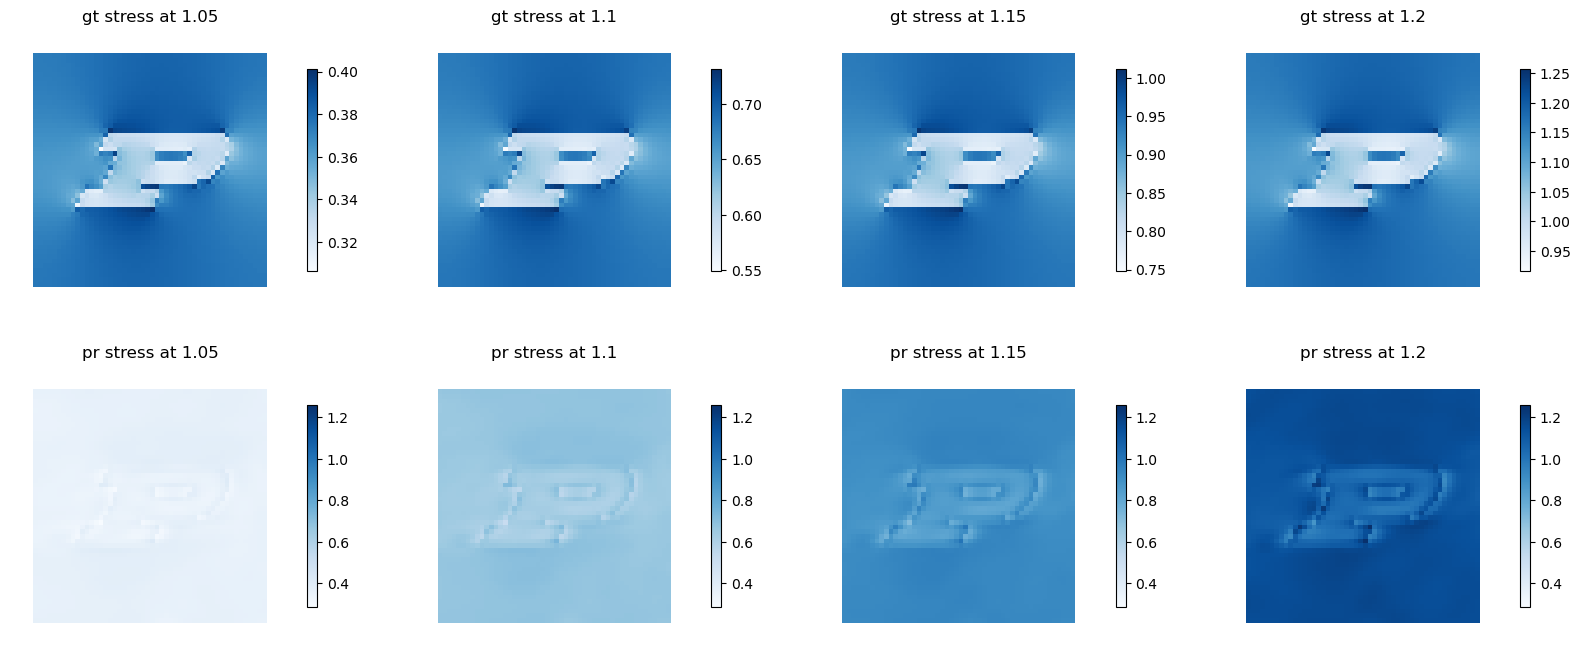

In [150]:
fig, axes = plt.subplots(2,4,figsize=(20,8))
id_f=0
for lmb, ax in zip(lmb_hist, axes.T):
    F=F_hist_goh[id_f]

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)
    # E = E_fun(F)
    # evals, efuns = jnp.linalg.eigh(E)
    # print(evals.shape)
    E_11, E_22 = evals.T
    c_elem_gt = []
    c_elem_pr = []
    id_elem=0
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        ugrad=jnp.squeeze(F[id_elem,:,:])-jnp.eye(2)
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        id_elem+=1
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0],ec='None'); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh_updated(mesh.cells, mesh.points, c_elem_pr, range_minmax[0],range_minmax[1],title=f'pr stress at {lmb}', ax=ax[1],ec='None')
    #plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend,ec='None');
    id_f+=1
 